# Experimenting with variations to LeNet's architecture
This is an attempt to improve the score at CIFAR-10

In [1]:
from tensorflow.keras import Sequential, layers, Model, callbacks
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow import pad, expand_dims, cast, float32, int32
from tensorflow.config import list_physical_devices
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import numpy as np

In [2]:
model_statistics = {}

# Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

y_train = cast(y_train, int32)
y_test = cast(y_test, int32)

x_train = cast(x_train, float32) / 255.0
x_test = cast(x_test, float32) / 255.0

x_val = x_train[:10000]
y_val = y_train[:10000]

x_train = x_train[10000:]
y_train = y_train[10000:]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


# Callbacks

In [4]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    start_from_epoch=10
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# Base Implementation (to test against)

## Definition

In [5]:
class LeNet(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=6, kernel_size=(5, 5), activation='tanh', input_shape=(32, 32, 3))
        self.pool2 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=16, kernel_size=(5, 5), activation='tanh')
        self.pool4 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(5, 5), activation='tanh')
        self.flat6 = layers.Flatten()
        self.dense7 = layers.Dense(units=84, activation='tanh')
        self.dense8 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.pool4(x)
        x = self.conv5(x)
        x = self.flat6(x)
        x = self.dense7(x)
        x = self.dense8(x)

        return x

In [6]:
base = LeNet()
base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "le_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [7]:
history = base.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.3536 - loss: 1.8194 - val_accuracy: 0.4065 - val_loss: 1.6907 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4274 - loss: 1.6238 - val_accuracy: 0.4628 - val_loss: 1.5134 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4793 - loss: 1.4660 - val_accuracy: 0.4907 - val_loss: 1.4226 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5099 - loss: 1.3741 - val_accuracy: 0.5195 - val_loss: 1.3522 - learning_rate: 0.0010
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5375 - loss: 1.3008 - val_accuracy: 0.5189 - val_loss: 1.3549 - learning_rate: 0.0010
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5545 - loss: 1.2488 - val_accuracy: 0.5352 - val_loss: 1.3172 - learning_rate: 0.0010
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.

In [8]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 12


In [9]:
model_statistics["LeNet Base"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": base.count_params(),
}

# Test 1: Replacing tanh with ReLU
The AlexNet paper mentions that deeper neural networks converge faster with ReLU as compared to tanh. Even if the current architecture doesn't benefit from this, it would still help in the later tests considerably.

## Definition

In [13]:
class LeNet_E1(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=6, kernel_size=(5, 5), activation='relu', kernel_initializer="he_normal", input_shape=(32, 32, 3))
        self.pool2 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=16, kernel_size=(5, 5), activation='relu', kernel_initializer="he_normal")
        self.pool4 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(5, 5), activation='relu', kernel_initializer="he_normal")
        self.flat6 = layers.Flatten()
        self.dense7 = layers.Dense(units=84, activation='relu', kernel_initializer="he_normal")
        self.dense8 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.pool4(x)
        x = self.conv5(x)
        x = self.flat6(x)
        x = self.dense7(x)
        x = self.dense8(x)

        return x

In [14]:
e1 = LeNet_E1()
e1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e1.summary()

Model: "le_net_e1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [15]:
history = e1.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4060 - loss: 1.6383 - val_accuracy: 0.4798 - val_loss: 1.4354 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5005 - loss: 1.3906 - val_accuracy: 0.4971 - val_loss: 1.4032 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5447 - loss: 1.2750 - val_accuracy: 0.5525 - val_loss: 1.2440 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5715 - loss: 1.2031 - val_accuracy: 0.5539 - val_loss: 1.2826 - learning_rate: 0.0010
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5975 - loss: 1.1356 - val_accuracy: 0.5738 - val_loss: 1.2099 - learning_rate: 0.0010
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6173 - loss: 1.0843 - val_accuracy: 0.5865 - val_loss: 1.1762 - learning_rate: 0.0010
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6

In [16]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 13


In [18]:
model_statistics["LeNet E1"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e1.count_params(),
}

Well that was unexpected. It increased the accuracy.

# Test 2: Reducing Conv Kernel Size
VGG uses 2x Conv with 3x3 kernel size instead of 1 with 5x5 size to reduce parameters and improve accuracy. Let's try that.

## Definition

In [19]:
class LeNet_E2(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=6, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=6, kernel_size=(3, 3), padding="same")
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same")
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.activation3 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.activation3(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [20]:
e2 = LeNet_E2()
e2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e2.summary()

Model: "le_net_e2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [21]:
history = e2.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4557 - loss: 1.5030 - val_accuracy: 0.5635 - val_loss: 1.2167 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6109 - loss: 1.1046 - val_accuracy: 0.6248 - val_loss: 1.0518 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6830 - loss: 0.8981 - val_accuracy: 0.6733 - val_loss: 0.9400 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7400 - loss: 0.7424 - val_accuracy: 0.6809 - val_loss: 0.9114 - learning_rate: 0.0010
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7861 - loss: 0.6091 - val_accuracy: 0.6773 - val_loss: 0.9681 - learning_rate: 0.0010
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8314 - loss: 0.4788 - val_accuracy: 0.6819 - val_loss: 1.0069 - learning_rate: 0.0010
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0

In [22]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [23]:
model_statistics["LeNet E2"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e2.count_params(),
}

# Test 3: Adding Batch Normalization
Batch Normalization is a technique to reduce overfitting.

## Definition

In [24]:
class LeNet_E3(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=6, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=6, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [25]:
e3 = LeNet_E3()
e3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e3.summary()

Model: "le_net_e3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [26]:
history = e3.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4518 - loss: 1.5154 - val_accuracy: 0.5507 - val_loss: 1.2778 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6173 - loss: 1.0902 - val_accuracy: 0.6487 - val_loss: 1.0219 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6880 - loss: 0.8930 - val_accuracy: 0.6899 - val_loss: 0.9069 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7367 - loss: 0.7574 - val_accuracy: 0.7039 - val_loss: 0.8531 - learning_rate: 0.0010
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7798 - loss: 0.6254 - val_accuracy: 0.7083 - val_loss: 0.8731 - learning_rate: 0.0010
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8201 - loss: 0.5137 - val_accuracy: 0.6915 - val_loss: 0.9426 - learning_rate: 0.0010
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.

In [27]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [28]:
model_statistics["LeNet E3"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e3.count_params(),
}

# Test 4: Increasing the number of filters
Increasing the number of filters should help capture more features

## Definition

In [29]:
class LeNet_E4(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [30]:
e4 = LeNet_E4()
e4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e4.summary()

Model: "le_net_e4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_8             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_9             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [31]:
history = e4.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.4690 - loss: 1.4705 - val_accuracy: 0.6124 - val_loss: 1.1045 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6474 - loss: 1.0027 - val_accuracy: 0.6787 - val_loss: 0.9218 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7175 - loss: 0.8074 - val_accuracy: 0.7196 - val_loss: 0.7925 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7646 - loss: 0.6790 - val_accuracy: 0.7203 - val_loss: 0.8161 - learning_rate: 0.0010
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8006 - loss: 0.5724 - val_accuracy: 0.7225 - val_loss: 0.8026 - learning_rate: 0.0010
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8322 - loss: 0.4798 - val_accuracy: 0.7395 - val_loss: 0.8025 - learning_rate: 0.0010
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0

In [32]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [33]:
model_statistics["LeNet E4"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e4.count_params(),
}

# Test 5: Replacing AveragePooling2D with MaxPooling2D
MaxPooling2D is more efficient than AveragePooling2D.

## Definition

In [34]:
class LeNet_E5(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.MaxPooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.MaxPooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [35]:
e5 = LeNet_E5()
e5.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e5.summary()

Model: "le_net_e5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [36]:
history = e5.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.4690 - loss: 1.4656 - val_accuracy: 0.5872 - val_loss: 1.1552 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6493 - loss: 1.0013 - val_accuracy: 0.6810 - val_loss: 0.9101 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7107 - loss: 0.8310 - val_accuracy: 0.6928 - val_loss: 0.8820 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7927 - loss: 0.5884 - val_accuracy: 0.7381 - val_loss: 0.7539 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8337 - loss: 0.4744 - val_accuracy: 0.7559 - val_loss: 0.7375 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8637 - loss: 0.3850 - val_accuracy: 0.7461 - val_loss: 0.8185 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - 

In [37]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [38]:
model_statistics["LeNet E5"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e5.count_params(),
}

This was a little disappointing but the accuracy is within margin of error.

# Test 6: Adding dropouts
The issue previously was the training accuracy hitting 1 near the end of each training session, which is a sign of overfitting, dropout should help reduce that.

## Definiton

In [39]:
class LeNet_E6(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout1 = layers.Dropout(0.2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout2 = layers.Dropout(0.2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.dropout1(x, training=training)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.dropout2(x, training=training)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [40]:
e6 = LeNet_E6()
e6.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e6.summary()

Model: "le_net_e6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [41]:
history = e6.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.4566 - loss: 1.4994 - val_accuracy: 0.5929 - val_loss: 1.1430 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6260 - loss: 1.0546 - val_accuracy: 0.6669 - val_loss: 0.9292 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6785 - loss: 0.9111 - val_accuracy: 0.6667 - val_loss: 0.9548 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7342 - loss: 0.7581 - val_accuracy: 0.7341 - val_loss: 0.7517 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7483 - loss: 0.7120 - val_accuracy: 0.7024 - val_loss: 0.8564 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7658 - loss: 0.6664 - val_accuracy: 0.7456 - val_loss: 0.7293 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - 

In [42]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 22


In [43]:
model_statistics["LeNet E6"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e6.count_params(),
}

Amazing.

# Test 7: Just One More Convolve Layer Bro


## Definition

In [44]:
class LeNet_E7(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout1 = layers.Dropout(0.2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout2 = layers.Dropout(0.2)
        self.conv5 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.pool3 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout3 = layers.Dropout(0.2)
        self.conv7 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.conv8 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.bn4 = layers.BatchNormalization()
        self.activation4 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.dropout1(x, training=training)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.dropout2(x, training=training)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.pool3(x)
        x = self.dropout3(x, training=training)
        x = self.conv7(x)
        x = self.conv8(x)
        x = self.bn4(x)
        x = self.activation4(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [45]:
e7 = LeNet_E7()
e7.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e7.summary()

Model: "le_net_e7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ ?                      │   0 (unbuilt

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [46]:
history = e7.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.4611 - loss: 1.4809 - val_accuracy: 0.4791 - val_loss: 1.5443 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6225 - loss: 1.0624 - val_accuracy: 0.6116 - val_loss: 1.1331 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6798 - loss: 0.9061 - val_accuracy: 0.7094 - val_loss: 0.8226 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7364 - loss: 0.7436 - val_accuracy: 0.7175 - val_loss: 0.8105 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7573 - loss: 0.6903 - val_accuracy: 0.7442 - val_loss: 0.7287 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7711 - loss: 0.6520 - val_accuracy: 0.7537 - val_loss: 0.6961 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step -

In [47]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 29


In [48]:
model_statistics["LeNet E7"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e7.count_params(),
}

Though this has gone deeper than planned, I want to get closer to 90% accuracy.

# Test 8: Dropout before dense layer

## Definition

In [49]:
class LeNet_E8(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout1 = layers.Dropout(0.2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout2 = layers.Dropout(0.2)
        self.conv5 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.pool3 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout3 = layers.Dropout(0.2)
        self.conv7 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.conv8 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.bn4 = layers.BatchNormalization()
        self.activation4 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dropout4 = layers.Dropout(0.4)
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.dropout1(x, training=training)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.dropout2(x, training=training)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.pool3(x)
        x = self.dropout3(x, training=training)
        x = self.conv7(x)
        x = self.conv8(x)
        x = self.bn4(x)
        x = self.activation4(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dropout4(x, training=training)
        x = self.dense2(x)

        return x

In [50]:
e8 = LeNet_E8()
e8.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e8.summary()

Model: "le_net_e8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ ?                      │   0 (unbuilt

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [51]:
history = e8.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.1895 - loss: 2.1058 - val_accuracy: 0.2387 - val_loss: 1.9785 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2610 - loss: 1.9061 - val_accuracy: 0.3459 - val_loss: 1.7395 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3693 - loss: 1.6451 - val_accuracy: 0.3819 - val_loss: 1.6527 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4621 - loss: 1.4362 - val_accuracy: 0.5195 - val_loss: 1.2876 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5162 - loss: 1.3241 - val_accuracy: 0.5938 - val_loss: 1.1156 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5600 - loss: 1.2355 - val_accuracy: 0.6061 - val_loss: 1.1056 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - 

In [52]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [53]:
model_statistics["LeNet E8"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e8.count_params(),
}

# Measuring Accuracy

In [61]:
loss, accuracy = base.evaluate(x_test, y_test)
model_statistics["LeNet Base"]["test_loss"] = loss
model_statistics["LeNet Base"]["test_accuracy"] = accuracy

loss, accuracy = e1.evaluate(x_test, y_test)
model_statistics["LeNet E1"]["test_loss"] = loss
model_statistics["LeNet E1"]["test_accuracy"] = accuracy

loss, accuracy = e2.evaluate(x_test, y_test)
model_statistics["LeNet E2"]["test_loss"] = loss
model_statistics["LeNet E2"]["test_accuracy"] = accuracy

loss, accuracy = e3.evaluate(x_test, y_test)
model_statistics["LeNet E3"]["test_loss"] = loss
model_statistics["LeNet E3"]["test_accuracy"] = accuracy

loss, accuracy = e4.evaluate(x_test, y_test)
model_statistics["LeNet E4"]["test_loss"] = loss
model_statistics["LeNet E4"]["test_accuracy"] = accuracy

loss, accuracy = e5.evaluate(x_test, y_test)
model_statistics["LeNet E5"]["test_loss"] = loss
model_statistics["LeNet E5"]["test_accuracy"] = accuracy

loss, accuracy = e6.evaluate(x_test, y_test)
model_statistics["LeNet E6"]["test_loss"] = loss
model_statistics["LeNet E6"]["test_accuracy"] = accuracy

loss, accuracy = e7.evaluate(x_test, y_test)
model_statistics["LeNet E7"]["test_loss"] = loss
model_statistics["LeNet E7"]["test_accuracy"] = accuracy

loss, accuracy = e8.evaluate(x_test, y_test)
model_statistics["LeNet E8"]["test_loss"] = loss
model_statistics["LeNet E8"]["test_accuracy"] = accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5554 - loss: 1.2996
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6299 - loss: 1.1554
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6923 - loss: 2.2623
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7093 - loss: 2.0030
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7474 - loss: 1.7176
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7413 - loss: 1.6777
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8085 - loss: 0.6000
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8302 - loss: 0.5018
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7184 - loss: 0.8180


# Plotting Results

In [54]:
from matplotlib import cm

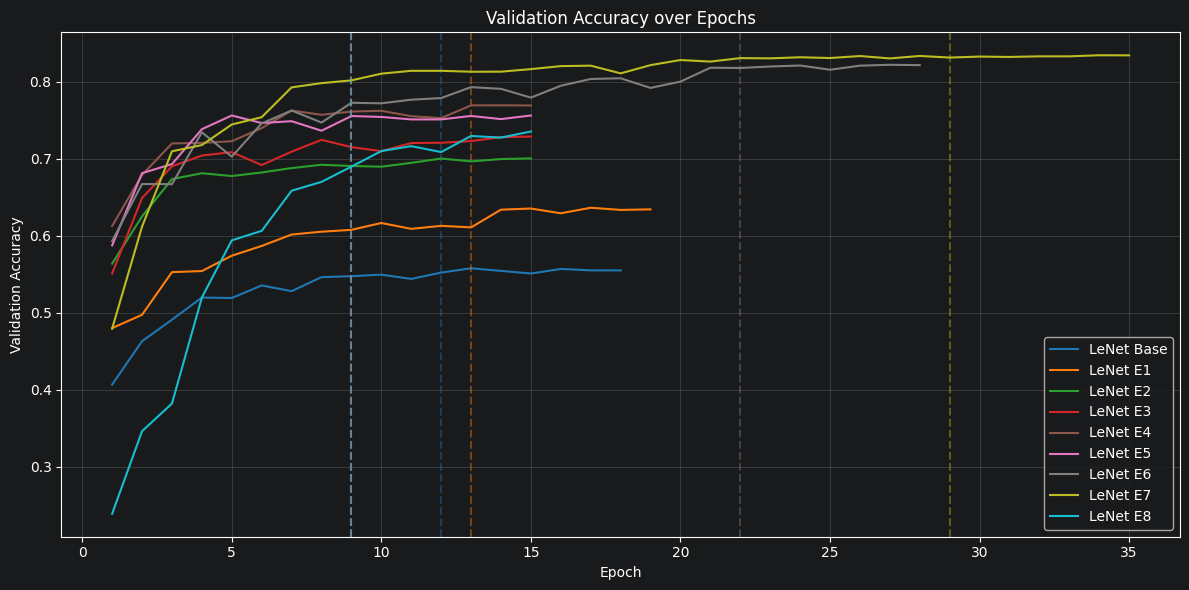

In [62]:
colors = cm.tab10(np.linspace(0, 1, len(model_statistics)))

fig, ax = plt.subplots(figsize=(12, 6))

for (name, stats), color in zip(model_statistics.items(), colors):
    val_acc = stats["history"].history["val_accuracy"]
    epochs  = range(1, len(val_acc) + 1)
    ax.plot(epochs, val_acc, label=name, color=color)
    ax.axvline(stats["convergence"], color=color, linestyle="--", alpha=0.4)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Validation Accuracy over Epochs")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

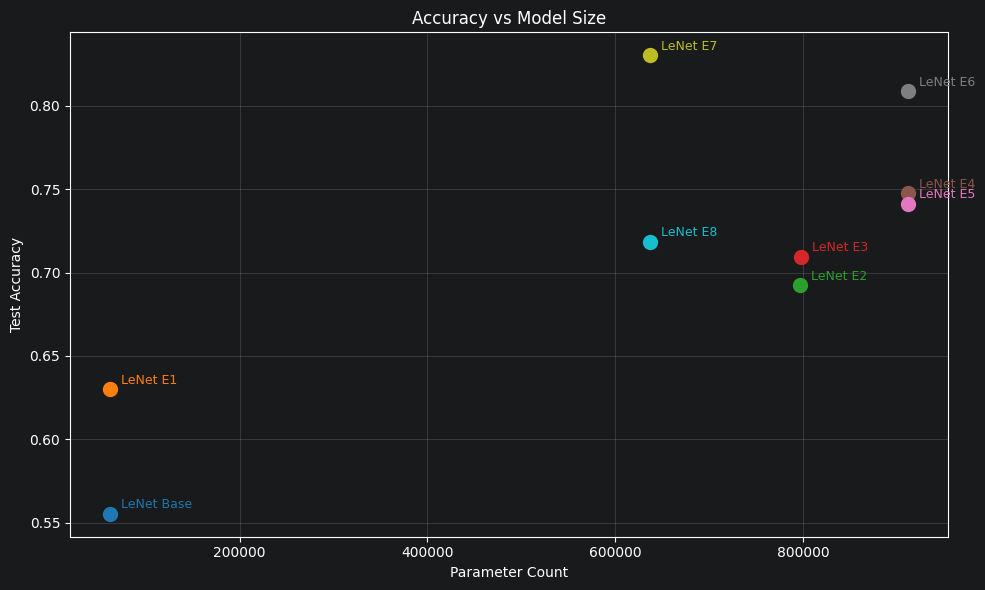

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))

for (name, stats), color in zip(model_statistics.items(), colors):
    final_acc = stats["test_accuracy"]
    params    = stats["parameters"]
    ax.scatter(params, final_acc, color=color, s=100, zorder=5)
    ax.annotate(name, (params, final_acc), textcoords="offset points", xytext=(8, 4), fontsize=9, color=color)

ax.set_xlabel("Parameter Count")
ax.set_ylabel("Test Accuracy")
ax.set_title("Accuracy vs Model Size")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()